# Cuaderno Jupyter de ejemplos para validación
## Paquete `traficFines`

En este cuaderno se comprueba el funcionamiento de las clases `Cache`, `CacheURL` y `MadridFines`, así como algunas excepciones.

In [1]:
import sys
sys.path.insert(0, '..')

from traficFines import Cache, CacheError, CacheURL, MadridError, MadridFines, get_url

## 1. Clase `Cache`

Pruebas de guardado, carga, borrado y errores.

In [2]:
cache = Cache(app_name="notebook_demo", obsolescence=1)

print(f"app_name: {cache.app_name}")
print(f"cache_dir: {cache.cache_dir}")
print(f"obsolescence: {cache.obsolescence} dias")

app_name: notebook_demo
cache_dir: /Users/nacho/.my_cache/notebook_demo
obsolescence: 1 dias


In [ ]:
cache.set("prueba1", "Dato de prueba 1")
cache.set("prueba2", "Dato de prueba 2")

print("¿Existe 'prueba1'?", cache.exists("prueba1"))
print("¿Existe 'no_existe'?", cache.exists("no_existe"))

Existe 'prueba1'? True
Existe 'no_existe'? False


In [4]:
dato = cache.load("prueba1")
print("Dato cargado:", dato)

Dato cargado: Dato de prueba 1


In [5]:
edad_ms = cache.how_old("prueba1")
print(f"Antiguedad: {edad_ms:.2f} ms")

Antiguedad: 45407.98 ms


In [8]:
cache.delete("prueba2")
print("¿Existe 'prueba2' tras delete()?", cache.exists("prueba2"))

cache.delete("elemento_inexistente")
if not cache.exists("elemento_inexistente"):
    print("delete() de elemento inexistente: sin error")

¿Existe 'prueba2' tras delete()? False
delete() de elemento inexistente: sin error


In [9]:
cache.set("a", "1")
cache.set("b", "2")
cache.clear()
print("¿Existe 'prueba1' despues de clear()?", cache.exists("prueba1"))
print("¿Existe 'a' despues de clear()?", cache.exists("a"))

¿Existe 'prueba1' despues de clear()? False
¿Existe 'a' despues de clear()? False


### Excepciones de `Cache`

In [10]:
try:
    cache.load("no_existe")
except CacheError as e:
    print("CacheError:", e)

CacheError: No existe no_existe en la caché.


In [11]:
try:
    cache.how_old("tampoco_existe")
except CacheError as e:
    print("CacheError:", e)

CacheError: No existe tampoco_existe en la caché.


## 2. Clase `CacheURL`

Comprobacion de descarga, reutilizacion de cache y borrado.

In [12]:
cache_url = CacheURL(app_name="demo_urls", obsolescence=7)
url_prueba = "https://datos.madrid.es/egob/catalogo/210104-395-multas-circulacion-detalle.csv"

print("¿Esta en cache?", cache_url.exists(url_prueba))

¿Esta en cache? False


In [15]:
print("Primera descarga:")
contenido = cache_url.get(url_prueba)
print(f"Caracteres descargados: {len(contenido)}")

print("¿Está ahora en caché?", cache_url.exists(url_prueba))

Primera descarga:
Caracteres descargados: 70444164
¿Está ahora en caché? True


In [17]:
print("Segunda descarga:")
contenido2 = cache_url.get(url_prueba)
print(f"Caracteres en la segunda descarga: {len(contenido2)}")
print("¿Es el mismo contenido que la primera descarga?", contenido == contenido2)

Segunda descarga:
Caracteres en la segunda descarga: 70444164
¿Es el mismo contenido que la primera descarga? True


In [18]:
edad = cache_url.how_old(url_prueba)
print(f"Antiguedad de la cache: {edad:.2f} ms")

Antiguedad de la cache: 92513.65 ms


In [19]:
cache_url.delete(url_prueba)
print("¿Existe el caché después de delete()?", cache_url.exists(url_prueba))

¿Existe el caché después de delete()? False


## 3. Funcion `get_url`

Comprobación con un caso valido y otro que debe fallar.

In [ ]:
try:
    url_dic2024 = get_url(year=2024, month=12)
    print("URL para 12/2024:", url_dic2024)
except MadridError as e:
    print("MadridError: ", e)

URL para 12/2024: https://datos.madrid.es/dataset/210104-0-multas-circulacion-detalle/resource/210104-15-multas-circulacion-detalle-csv/download/210104-15-multas-circulacion-detalle-csv.csv


In [21]:
try:
    get_url(year=1990, month=1)
except MadridError as e:
    print("MadridError: ", e)

MadridError:  Año inválido: 1990


## 4. Clase `MadridFines`

Comprobación de carga de datos, meses repetidos, graficos y resúmenes.

In [23]:
mf = MadridFines(app_name="test_multas", obsolescence=30)

print("Meses cargados al inicio:", mf.loaded)
print("DataFrame vacio al inicio:", mf.data.empty)

Meses cargados al inicio: []
DataFrame vacio al inicio: True


In [25]:
print("Cargando diciembre de 2024:")
mf.add(2024, 12)

print("Meses cargados:", mf.loaded)
print("Filas en el DataFrame:", len(mf.data))
mf.data.head()

Cargando diciembre de 2024:
Meses cargados: [(12, 2024)]
Filas en el DataFrame: 249801


,CALIFICACION,LUGAR,MES,ANIO,HORA,IMP_BOL,DESCUENTO,PUNTOS,DENUNCIANTE,HECHO-BOL,VEL_LIMITE,VEL_CIRCULA,COORDENADA-X,COORDENADA-Y
fecha,,,,,,,,,,,,,,
2024-12-01 20:23:00,LEVE,CL CLARA DEL REY 36,12,2024,20.23,60.0,SI,0,SER,ESTACIONAR CON AUTORIZACIÓN NO VÁLIDA.,NaN,NaN,NaN,NaN
2024-12-01 20:27:00,LEVE,CL CLARA DEL REY 28,12,2024,20.27,90.0,SI,0,SER,"ESTACIONAR, SIN LA CORRESPONDIENTE AUTORIZACIÓ...",NaN,NaN,NaN,NaN
2024-12-01 20:45:00,GRAVE,CL CANILLAS 63,12,2024,20.45,200.0,SI,0,SER,ESTACIONAR OBSTACULIZANDO LA UTILIZACIÓN DE UN...,NaN,NaN,NaN,NaN
2024-12-01 16:30:00,LEVE,CL BRAVO MURILLO 24,12,2024,16.30,60.0,SI,0,SER,ESTACIONAR CON AUTORIZACIÓN NO VÁLIDA.,NaN,NaN,NaN,NaN
2024-12-01 16:50:00,LEVE,CL BRAVO MURILLO 16,12,2024,16.50,90.0,SI,0,SER,"ESTACIONAR, SIN LA CORRESPONDIENTE AUTORIZACIÓ...",NaN,NaN,NaN,NaN


In [27]:
filas_antes = len(mf.data)
mf.add(2024, 12)
filas_despues = len(mf.data)

print("Filas antes:", filas_antes)
print("Filas tras carga de los mismos datos:", filas_despues)
print("¿Se han duplicado?", filas_antes != filas_despues)

Filas antes: 249801
Filas tras carga de los mismos datos: 249801
¿Se han duplicado? False


### Cargar varios meses

In [28]:
mf.add(2024, 11)
print("Meses cargados:", mf.loaded)
print("Total de filas:", len(mf.data))

Meses cargados: [(12, 2024), (11, 2024)]
Total de filas: 503914


### Grafico de multas por hora

Grafico guardado en evolucion_multas.png


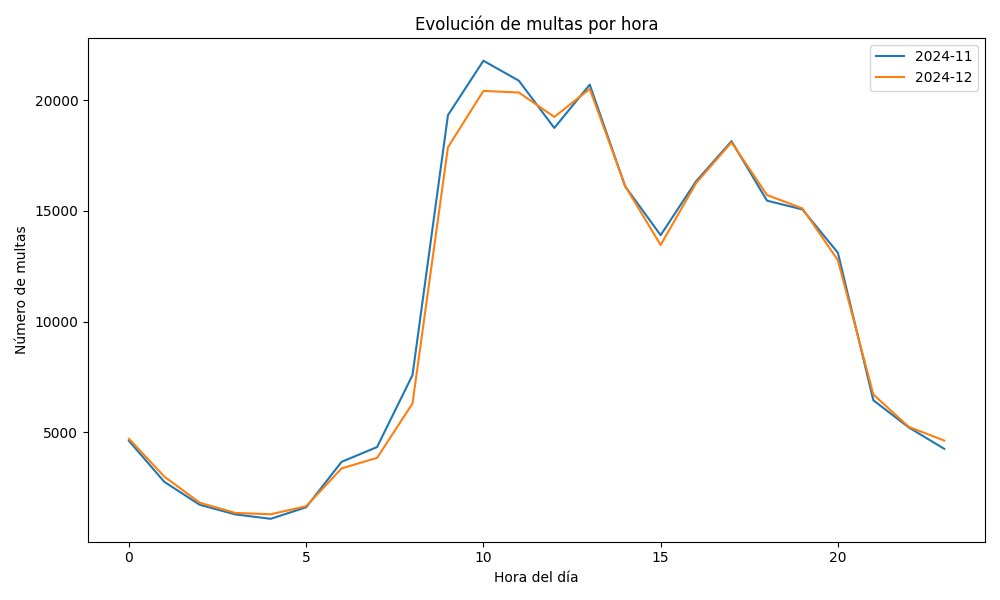

In [ ]:
mf.fines_hour("evolucion_multas.png")
print("Gráfico guardado en evolucion_multas.png")

from IPython.display import Image
Image("evolucion_multas.png")

### Resumen por calificacion

In [30]:
df_cal = mf.fines_calification()
print("Resumen por calificacion:")
df_cal

Resumen por calificacion:


,CALIFICACION,GRAVE,LEVE,MUY GRAVE
MES,ANIO,,,
11,2024,156519,96829,765
12,2024,157605,91388,808


### Resumen de importes

In [31]:
df_pagos = mf.total_payment()
print("Resumen de importes por mes y año:")
df_pagos

Resumen de importes por mes y año:


,,total_min,total_max
MES,ANIO,,
11,2024,18381030.0,36762060.0
12,2024,18502615.0,37005230.0


### Excepciones de `MadridFines`

In [34]:
mf_vacio = MadridFines(app_name="test_vacio")

try:
    mf_vacio.fines_hour("test.png")
except MadridError as e:
    print("MadridError:", e)

MadridError: No hay datos cargados.


In [35]:
try:
    mf_vacio.fines_calification()
except MadridError as e:
    print("MadridError:", e)

MadridError: No hay datos cargados.


In [ ]:
try:
    mf_vacio.total_payment()
except MadridError as e:
    print("MadridError:", e)

MadridError capturado: No hay datos cargados.


In [38]:
try:
    mf_vacio.add(1990, 1)
except MadridError as e:
    print("MadridError:", e)

MadridError: Año inválido: 1990


## 5. Comprobacion de las propiedades

Comprobación de que `loaded` y `data` se consultan desde fuera sin modificar el estado interno.

In [39]:
loaded_copy = mf.loaded
data_copy = mf.data

loaded_copy.append((1, 2000))
data_copy["NUEVA_COLUMNA"] = 1

print("Meses cargados originales:", mf.loaded)
print("Forma original del DataFrame:", mf.data.shape)
print("La copia de loaded no cambia el objeto:", (1, 2000) not in mf.loaded)
print("La copia de data no cambia el objeto:", "NUEVA_COLUMNA" not in mf.data.columns)

Meses cargados originales: [(12, 2024), (11, 2024)]
Forma original del DataFrame: (503914, 14)
La copia de loaded no cambia el objeto: True
La copia de data no cambia el objeto: True
